<a href="https://colab.research.google.com/github/vladgap/Various/blob/main/2D_3D_3D%2B_function_approximation_180126.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [234]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from sklearn import preprocessing
import matplotlib.pyplot as plt
import skimage.io as sio
pd.options.plotting.backend = "plotly"

import tensorflow as tf
from tensorflow import keras

In [2]:
# pip install MLNN

In [3]:
# from MLNN import*

In [4]:
!wget -O MLNN.py "https://raw.githubusercontent.com/vladgap/MLNN/main/MLNN_3_2.py"
from MLNN import *

--2026-01-18 08:56:33--  https://raw.githubusercontent.com/vladgap/MLNN/main/MLNN_3_2.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14169 (14K) [text/plain]
Saving to: ‘MLNN.py’

MLNN.py             100%[===================>]  13.84K  --.-KB/s    in 0s      

2026-01-18 08:56:33 (80.1 MB/s) - ‘MLNN.py’ saved [14169/14169]

Version of MLNN is 3.2


In [5]:
!wget -O tools.py "https://raw.githubusercontent.com/vladgap/Various/main/tools.py"
from tools import *
## CopyPasteToPandas CopyPasteToArray print_scaler_data Fit2to1

--2026-01-18 08:56:33--  https://raw.githubusercontent.com/vladgap/Various/main/tools.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6465 (6.3K) [text/plain]
Saving to: ‘tools.py’

tools.py            100%[===================>]   6.31K  --.-KB/s    in 0s      

2026-01-18 08:56:33 (46.6 MB/s) - ‘tools.py’ saved [6465/6465]

Version of vladgap_tools is 0.4


# f(x) -- simple porabola as is

In [256]:
def func(x):
    y = x**2-1
    return y

In [257]:
x=np.linspace(-1,2,11)
data1=np.array([
               x,
               func(x)
               ]).T
X1=data1[:,[0]]
T1=data1[:,[1]]

## MLNN

In [323]:
bp1=VectorBackProp(layers=[1,2,1], hidden_activation = 'prelu')

In [324]:
bp1.fit(X1, T1, epochs=2000, learning_rate = 0.005, momentum_term = 0.8)
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
fig1.show()

Initial loss = 1.5931110023814339
Final loss = 0.03780000000000001


In [325]:
predics1=bp1.run(X1)
# predics1

In [326]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

/tmp/ipython-input-4151572383.py:1: RuntimeWarning:

divide by zero encountered in divide



In [327]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

# Set y-axes titles
fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [328]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=bp1.run(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_xaxes(title_text="R(Sol.)")

# Set y-axes titles
fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-200, 200], secondary_y=True, showgrid=False)#, tick0=-5, dtick=2)

fig.show()

In [329]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 2, 1] prelu linear
Hidden layer weights:  [[-1.0650196707323505, -1.7540480118080815]]
Hidden layer biases:  [[2.1340244848093297, 0.7016192047232319]]
Outlet layer weights:  [[-2.3504761199217374], [1.8832456586511788]]
Outlet layer biases:  [[2.714652269551299]]


In [330]:
bp1.export_weights_as_pandas()

,0,1
0,-1.065020,-1.754048
0,2.134024,0.701619
0,-2.350476,NaN
1,1.883246,NaN
0,2.714652,NaN


## TensorFlow

In [296]:
# Модель
model = keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(2),
    keras.layers.PReLU(alpha_initializer=keras.initializers.Constant(0.001),trainable=False), # чтобы alpha не менялся при обучении
    # keras.layers.Activation('sigmoid'),
    keras.layers.Dense(1, activation='linear')
])

In [299]:
# Компиляция и обучение
optimizer = keras.optimizers.SGD(learning_rate=0.005, momentum=0.8)
model.compile(optimizer=optimizer, loss='mse')
history = model.fit(X1, T1, epochs=2000, verbose=0)

In [300]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=history.history['loss'][20:], name=''))
print('Initial loss =', history.history['loss'][0])
print('Final loss =', history.history['loss'][-1])
fig1.show()

Initial loss = 0.8103549480438232
Final loss = 0.11159829795360565


In [301]:
# # Предсказание
predics1 = model.predict(X1)
print("Predictions:", predics1.flatten())
errors1=(predics1-T1)/T1*100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predictions: [-0.7921133  -0.7769246  -0.75244427 -0.7101116  -0.6316304  -0.47923064
 -0.18458605  0.33755994  1.0969167   1.9169372   2.5588417 ]


/tmp/ipython-input-2740486225.py:4: RuntimeWarning:

divide by zero encountered in divide



In [302]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=model.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_xaxes(title_text="R(Sol.)")

# Set y-axes titles
fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-200, 200], secondary_y=True, showgrid=False)#, tick0=-5, dtick=2)

fig.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [292]:
# # Экспорт весов
all_weights = model.get_weights()
print("\nExported weights:", [w.tolist() for w in all_weights])


Exported weights: [[[-0.6088459491729736, 1.5004572868347168]], [-0.39223840832710266, -1.0660314559936523], [0.0010000000474974513, 0.0010000000474974513], [[-0.03639107942581177], [1.7778209447860718]], [-0.6851159930229187]]


In [294]:
# Экспорт в pandas (аналог export_weights_as_pandas)
df = pd.concat([pd.DataFrame(w) for w in all_weights], axis=0, ignore_index=True)
print("\nWeights as DataFrame:")
df


Weights as DataFrame:


,0,1
0,-0.608846,1.500457
1,-0.392238,NaN
2,-1.066031,NaN
3,0.001000,NaN
4,0.001000,NaN
5,-0.036391,NaN
6,1.777821,NaN
7,-0.685116,NaN


# f(x) -- simple porabola

In [159]:
def func(x):
    y = x**2-1
    return y

In [160]:
x=np.linspace(-1,2,11)
data1=np.array([
               x,
               func(x)
               ]).T
X1=data1[:,[0]]
T1=data1[:,[1]]

## scaling

In [161]:
scaler_X1 = preprocessing.StandardScaler().fit(X1)
scaler_T1 = preprocessing.StandardScaler().fit(T1)

# scaler_X1.mean_, scaler_X1.scale_ = 0, 1 # disable scaling
# scaler_T1.mean_, scaler_T1.scale_ = 0, 1 # disable scaling

scaler_data1 = [scaler_X1.mean_, scaler_X1.scale_, scaler_T1.mean_, scaler_T1.scale_]
print('scaler X -- mean, stdev:  ',scaler_data1[0], scaler_data1[1])
print('scaler T -- mean, stdev:  ',scaler_data1[2], scaler_data1[3])

X_sc1 = scaler_X1.transform(X1)
T_sc1 = scaler_T1.transform(T1)
X_sc1[0:3]

scaler X -- mean, stdev:   [0.5] [0.9486833]
scaler T -- mean, stdev:   [0.15] [1.23765908]


array([[-1.58113883],
       [-1.26491106],
       [-0.9486833 ]])

In [162]:
def print_scaler_data(scaler_data):
    print('scaler X -- mean, stdev:  ',scaler_data[0], scaler_data[1])
    print('scaler T -- mean, stdev:  ',scaler_data[2], scaler_data[3])

## parameter searching

In [163]:
bp_iter=VectorBackProp(layers=[1,2,1], hidden_activation = 'prelu')
learning_rate = [0.001, 0.005, 0.01]
momentum_term = [0.8, 0.9, 0.95]
learning_rate_decay = [0]
repeats = range(5)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X_sc1, T_sc1, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                i+=1


total runs: 45
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 

In [164]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
0,0.001,0.8,0.0,0.048308,-1.075840e-05
1,0.001,0.8,0.0,1.000007,-1.973480e-07
2,0.001,0.8,0.0,0.025292,-1.299612e-01
3,0.001,0.8,0.0,0.412456,0.000000e+00
4,0.001,0.8,0.0,0.024687,-5.697868e-04


In [165]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.2],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [166]:
bp_iter=VectorBackProp(layers=[1,2,1], hidden_activation = 'prelu')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X_sc1, T_sc1, epochs=1000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [167]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.05], title='Loss')
fig2.show()

In [168]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=relative_delta_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[-0.5, 0.5], title='Relative delta')
fig2.show()

### Loss and relative delta

In [169]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
[fig.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i),secondary_y=False) for i in range(n)]
[fig.add_trace(go.Scatter(y=relative_delta_lists2[i][100:], name=i),secondary_y=True) for i in range(n)]

fig.update_xaxes(title_text="data")
fig.update_yaxes(title_text="loss", secondary_y=False)
fig.update_yaxes(title_text="relative_delta", secondary_y=True, showgrid=False, range=[-0.01, 0.01], tick0=-0.01, dtick=.0025)
fig.update_layout(title='Loss and relative delta')
fig.show()

## best_weights_for_now

In [170]:
best_weights_for_now1=weights_lists2[9]
best_weights_for_now1

[[[1.4534653799076416, -0.07440007288688855]],
 [[-0.3869767069915598, -0.11881872707032717]],
 [[1.4761769512116973], [0.08991152927726495]],
 [[-0.6643081123198792]]]

In [171]:
manual_best_weights_for_now1=[[[1.4679720656402142, -0.8772555603112121]],
 [[-0.2642898586862683, -0.7960946401657086]],
 [[1.4626702878650846], [1.1753619308048402]],
 [[-0.8485569587771513]]]

 # relu
 # epochs=1000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 0
 # loss = .0091

## fitting best parameters

In [172]:
bp1=VectorBackProp(layers=[1,2,1], hidden_activation = 'prelu')

In [173]:
# bp1.import_weights(best_weights_for_now1)
bp1.import_weights(manual_best_weights_for_now1)
bp1.fit(X_sc1, T_sc1, epochs=2000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 1, repeat=True)

In [174]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
# fig1.show()

Initial loss = 0.0091049855944423
Final loss = 0.009102103519323014


## prediction

In [175]:
predics1=scaler_T1.inverse_transform(bp1.run(X_sc1))
predics1

array([[-0.04461948],
       [-0.44801852],
       [-0.85141756],
       [-0.90264169],
       [-0.90220557],
       [-0.90176944],
       [-0.53987344],
       [ 0.30008534],
       [ 1.14004413],
       [ 1.98000291],
       [ 2.81996169]])

In [176]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

/tmp/ipython-input-4151572383.py:1: RuntimeWarning:

divide by zero encountered in divide



In [177]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

# Set y-axes titles
fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [178]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=scaler_T1.inverse_transform(bp1.run(scaler_X1.transform(X_extended.reshape(51,1))))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_xaxes(title_text="R(Sol.)")

# Set y-axes titles
fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [179]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 2, 1] prelu linear
Hidden layer weights:  [[1.4679699756840732, -0.8778327941107612]]
Hidden layer biases:  [[-0.2643441387869522, -0.7972742027745297]]
Outlet layer weights:  [[1.4626779990950032], [1.1765917823136625]]
Outlet layer biases:  [[-0.848480741647742]]


In [180]:
bp1.export_weights_as_pandas()

,0,1
0,1.467970,-0.877833
0,-0.264344,-0.797274
0,1.462678,NaN
1,1.176592,NaN
0,-0.848481,NaN


In [181]:
print (*scaler_data1)

[0.5] [0.9486833] [0.15] [1.23765908]


In [182]:
print_scaler_data(scaler_data1)

scaler X -- mean, stdev:   [0.5] [0.9486833]
scaler T -- mean, stdev:   [0.15] [1.23765908]


# f(x) -- sigmoids

In [183]:
data=CopyPasteToArray('''
MgCl2	H2O
84.0	65.2
86.9	65.4
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
95.1	64.7
97.8	63.4
98.5	62.4
99.2	60.8
''')
# data
data1=pd.DataFrame(data[1:], columns=data[0])
# data1

In [184]:
X1=np.array(data1)[:,[0]]
T1=np.array(data1)[:,[1]]

## scaling

In [185]:
scaler_X1 = preprocessing.StandardScaler().fit(X1)
scaler_T1 = preprocessing.StandardScaler().fit(T1)

# scaler_X1.mean_, scaler_X1.scale_ = 0, 1 # disable scaling
# scaler_T1.mean_, scaler_T1.scale_ = 0, 1 # disable scaling

scaler_data1 = [scaler_X1.mean_, scaler_X1.scale_, scaler_T1.mean_, scaler_T1.scale_]
print('scaler X -- mean, stdev:  ',scaler_data1[0], scaler_data1[1])
print('scaler T -- mean, stdev:  ',scaler_data1[2], scaler_data1[3])

X_sc1 = scaler_X1.transform(X1)
T_sc1 = scaler_T1.transform(T1)
X_sc1[0:3]

scaler X -- mean, stdev:   [89.04482759] [4.85092143]
scaler T -- mean, stdev:   [64.92068966] [0.99286396]


array([[-1.03997306],
       [-0.44214849],
       [ 0.48551032]])

In [186]:
def print_scaler_data(scaler_data):
    print('scaler X -- mean, stdev:  ',scaler_data[0], scaler_data[1])
    print('scaler T -- mean, stdev:  ',scaler_data[2], scaler_data[3])

## parameter searching

In [187]:
bp_iter=VectorBackProp(layers=[1,3,1], hidden_activation = 'sigmoid')
learning_rate = [0.01, 0.02, 0.05]
momentum_term = [0.97, 0.98, 0.99]
learning_rate_decay = [0]
repeats = range(5)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X_sc1, T_sc1, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                i+=1


total runs: 45
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 

/content/MLNN.py:37: RuntimeWarning:

overflow encountered in exp



40 41 42 43 44 

In [188]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.sort_values('final_loss').head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
20,0.02,0.98,0.0,0.000020,-0.186514
7,0.01,0.98,0.0,0.000029,-0.505874
5,0.01,0.98,0.0,0.000066,-0.188062
4,0.01,0.97,0.0,0.000072,-0.087046
6,0.01,0.98,0.0,0.000107,-0.308982


In [189]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.01],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [190]:
bp_iter=VectorBackProp(layers=[1,3,1], hidden_activation = 'sigmoid')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X_sc1, T_sc1, epochs=4000, learning_rate = 0.02, momentum_term = 0.97, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [191]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.05], title='Loss')
fig2.show()

## best_weights_for_now

In [192]:
best_weights_for_now1=weights_lists2[17]
best_weights_for_now1

[[[5.127217522091002, -0.510802794928031, 3.73404972323764]],
 [[5.565127270098637, -1.3077522054672965, -8.868697128865149]],
 [[1.1097302561170845], [2.8033924906389442], [-16.289613466905315]],
 [[-1.221446992829034]]]

In [193]:
manual_best_weights_for_now1=[[[2.6660729389968933, 8.702569039917602, 5.084077058616787]],
 [[-4.240766516973194, -18.09915585938534, 6.430961348484185]],
 [[-2.5384999348250927], [-4.996673721562352], [0.9318623741741148]],
 [[-0.42308370415538205]]]

 # 3 sigmoids
 # epochs=1000, learning_rate = 0.02, momentum_term = 0.97, learning_rate_decay = 0
 # loss = 3e-8

## fitting best parameters

In [194]:
bp1=VectorBackProp(layers=[1,3,1], hidden_activation = 'sigmoid')

In [195]:
# bp1.import_weights(best_weights_for_now1)
bp1.import_weights(manual_best_weights_for_now1)
bp1.fit(X_sc1, T_sc1, epochs=2000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 1, repeat=True)

In [196]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
# fig1.show()

Initial loss = 3.4189905846678e-08
Final loss = 3.417341369067094e-08


## prediction

In [197]:
predics1=scaler_T1.inverse_transform(bp1.run(X_sc1))
# predics1

In [198]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

In [199]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

# Set y-axes titles
fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [200]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=scaler_T1.inverse_transform(bp1.run(scaler_X1.transform(X_extended.reshape(51,1))))[:,0], mode='markers', marker_size=3, name='extenden prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_xaxes(title_text="")

# Set y-axes titles
fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-1, 1], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.update_layout(
    width=1000, height=1000,
)

fig.show()

In [201]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 3, 1] sigmoid linear
Hidden layer weights:  [[2.6660766229355577, 8.702569926923932, 5.084075916060919]]
Hidden layer biases:  [[-4.240768539485954, -18.099156682657366, 6.430961139304303]]
Outlet layer weights:  [[-2.53849464126827], [-4.996674214675649], [0.9318620094716186]]
Outlet layer biases:  [[-0.4230836116131165]]


In [202]:
bp1.export_weights()

[[[2.6660766229355577, 8.702569926923932, 5.084075916060919]],
 [[-4.240768539485954, -18.099156682657366, 6.430961139304303]],
 [[-2.53849464126827], [-4.996674214675649], [0.9318620094716186]],
 [[-0.4230836116131165]]]

In [203]:
bp1.export_weights_as_pandas()

,0,1,2
0,2.666077,8.702570,5.084076
0,-4.240769,-18.099157,6.430961
0,-2.538495,NaN,NaN
1,-4.996674,NaN,NaN
2,0.931862,NaN,NaN
0,-0.423084,NaN,NaN


In [204]:
pd.DataFrame(scaler_data1)

,0
0,89.044828
1,4.850921
2,64.920690
3,0.992864


In [205]:
print (*scaler_data1)

[89.04482759] [4.85092143] [64.92068966] [0.99286396]


In [206]:
print_scaler_data(scaler_data1)

scaler X -- mean, stdev:   [89.04482759] [4.85092143]
scaler T -- mean, stdev:   [64.92068966] [0.99286396]


# f(x1,x2) -- Fit2to1

In [54]:
data=CopyPasteToArray('''
T	NaCl	KCl	MgCl2	TDS	H2O
55	0.0	0.0	100.0	37.6	62.5
55	0.0	0.6	99.4	37.6	62.4
55	0.0	1.7	98.3	37.5	62.5
55	0.0	13.4	86.6	33.2	66.8
55	0.0	30.1	69.9	32.5	67.5
55	0.0	49.4	50.6	29.9	70.1
55	0.0	76.4	23.6	30.6	69.4
83	0.0	0.0	100.0	39.8	60.2
83	0.0	2.6	97.4	38.8	61.2
83	0.0	6.4	93.6	39.5	60.5
83	0.0	16.5	83.5	35.3	64.8
83	0.0	38.3	61.7	33.3	66.7
83	0.0	55.6	44.4	32.9	67.1
83	0.0	79.0	21.0	34.0	66.0
105	0.0	0.0	100.0	43.5	56.5
105	0.0	2.6	97.4	41.8	58.2
105	0.0	9.0	91.0	40.1	59.9
105	0.0	18.5	81.5	37.8	62.2
105	0.0	40.9	59.1	36.3	63.7
105	0.0	60.7	39.3	35.8	64.2
105	0.0	61.0	39.0	35.8	64.2
105	0.0	82.1	17.9	36.4	63.6
105	0.0	100.0	0.0	36.5	63.6
''')
# data
data1=pd.DataFrame(data[1:], columns=data[0])
# data1

In [55]:
fig=go.Figure()
fig.add_trace(go.Scatter3d(x=data1['MgCl2'], y=data1['T'], z=data1['H2O'], mode='markers'))
fig.show()

In [56]:
X1=np.array(data1)[:,[3,0]]
T1=np.array(data1)[:,[5]]

In [57]:
scaler_X1 = preprocessing.StandardScaler().fit(X1)
scaler_T1 = preprocessing.StandardScaler().fit(T1)

# scaler_X1.mean_, scaler_X1.scale_ = 0, 1 # disable scaling
# scaler_T1.mean_, scaler_T1.scale_ = 0, 1 # disable scaling

scaler_data1 = [scaler_X1.mean_, scaler_X1.scale_, scaler_T1.mean_, scaler_T1.scale_]
print('scaler X -- mean, stdev:  ',scaler_data1[0], scaler_data1[1])
print('scaler T -- mean, stdev:  ',scaler_data1[2], scaler_data1[3])

X_sc1 = scaler_X1.transform(X1)
T_sc1 = scaler_T1.transform(T1)
X_sc1[0:3]

scaler X -- mean, stdev:   [67.6173913  83.08695652] [31.35734644 20.68797812]
scaler T -- mean, stdev:   [63.64347826] [3.34336801]


array([[ 1.03269608, -1.35764628],
       [ 1.01356181, -1.35764628],
       [ 0.97848231, -1.35764628]])

In [58]:
x_mesh, y_mesh = np.linspace(-10, 110, 31), np.linspace(50, 110, 31) # more expanded x and y extrapolation area observation
x_mesh, y_mesh = np.meshgrid(x_mesh, y_mesh)
x_mesh1 = x_mesh.flatten().reshape(31*31,1)
y_mesh1 = y_mesh.flatten().reshape(31*31,1)
mesh1=np.concatenate((x_mesh1, y_mesh1), axis=1)
# x_mesh1[:5]

In [59]:
K_Mg=Fit2to1(X1, T1, mesh1, confidences=None, hidden_layers=2, hidden_activation='sigmoid')

In [60]:
K_Mg.fit_model(epochs=1000, learning_rate = 0.001, momentum_term = 0.95)

Initial loss = 1.0033255848972993
Final loss = 0.023991596365994104


In [61]:
K_Mg.export_weights()

Hidden layers: 2
Hidden activation: sigmoid
Loss: 0.023991596365994104 



[[[0.2781903422951869, -3.3641199563071953],
  [-1.9424424462780607, 0.002699659876733201]],
 [[0.22340084028162407, 2.758404839647525]],
 [[1.9851282458321833], [3.2836021016237322]],
 [[-3.3830466949408966]]]

In [62]:
weights=[[[3.143857432839991, -0.3066603060724277],
  [0.022284499400146266, 1.6567259445000657]],
 [[-2.738308910716288, -0.2964859809746444]],
 [[-3.647884133545059], [-2.1431252443596716]],
 [[1.9503737123940939]]]

K_Mg.import_weights(weights)

In [63]:
K_Mg.show()

In [64]:
K_Mg.print_weights()

Layers (input, hidden, output):  [2, 2, 1] sigmoid linear
Hidden layer weights:  [[3.143857432839991, -0.3066603060724277], [0.022284499400146266, 1.6567259445000657]]
Hidden layer biases:  [[-2.738308910716288, -0.2964859809746444]]
Outlet layer weights:  [[-3.647884133545059], [-2.1431252443596716]]
Outlet layer biases:  [[1.9503737123940939]]


In [65]:
K_Mg.print_scaler_data()

scaler X -- mean, stdev:   [67.6173913  83.08695652] [31.35734644 20.68797812]
scaler T -- mean, stdev:   [63.64347826] [3.34336801]


In [66]:
df=[
[20,60],
[40,60],
[60,60],
[80,60],
[90,60],
[95,60],
]
K_Mg_predics=scaler_T1.inverse_transform(K_Mg.network.run(scaler_X1.transform(df)))
K_Mg_result=pd.concat([pd.DataFrame(df),pd.DataFrame(K_Mg_predics)], axis=1)
K_Mg_result.columns = ['MgCl2', 'T', 'H2O']
K_Mg_result

,MgCl2,T,H2O
0,20,60,69.031838
1,40,60,69.163691
2,60,60,69.013758
3,80,60,67.305490
4,90,60,64.998595
5,95,60,63.531702


In [67]:
K_Mg.network.export_weights_as_pandas()

,0,1
0,3.143857,-0.306660
1,0.022284,1.656726
0,-2.738309,-0.296486
0,-3.647884,NaN
1,-2.143125,NaN
0,1.950374,NaN


# f(x1,x2) -- x1^3-0.2*x2+5


f=x1^3-0.2*x2+5

In [68]:
data4=[
[0.32,	0.99,	0.77,	0.69,	0.04,	0.37,	0.25,	0.44,	0.42,	0.64,	0.8,],
[0.4,	0.23,	0.22,	0.57,	0.78,	0.69,	0.2,	0.45,	0.17,	0.98,	0.96,],
[4.952768,	5.924299,	5.412533,	5.214509,	4.844064,	4.912653,	4.975625,	4.995184,	5.040088,	5.066144,	5.32,],
]
data4=np.array(data4).T
X4=data4[:,[0,1]]
T4=data4[:,[2]]

In [69]:
# data4[:,0]**3-0.2*data4[:,1]+5

## scaling

In [70]:
scaler_X4 = preprocessing.StandardScaler().fit(X4)
scaler_T4 = preprocessing.StandardScaler().fit(T4)

# scaler_X4.mean_, scaler_X4.scale_ = 0, 1 # disable scaling
# scaler_T4.mean_, scaler_T4.scale_ = 0, 1 # disable scaling

scaler_data4 = [scaler_X4.mean_, scaler_X4.scale_, scaler_T4.mean_, scaler_T4.scale_]
print('scaler X -- mean, stdev:  ',scaler_data4[0], scaler_data4[1])
print('scaler T -- mean, stdev:  ',scaler_data4[2], scaler_data4[3])

X_sc4 = scaler_X4.transform(X4)
T_sc4 = scaler_T4.transform(T4)
X_sc4[0:3]

scaler X -- mean, stdev:   [0.52090909 0.51363636] [0.26752925 0.28952226]
scaler T -- mean, stdev:   [5.15071518] [0.29600926]


array([[-0.7509799 , -0.39249612],
       [ 1.75341913, -0.97967031],
       [ 0.93107915, -1.01420996]])

In [71]:
bp4=VectorBackProp(layers=[2,4,1], hidden_activation = 'prelu')

## fitting

In [72]:
bp4.fit(X_sc4, T_sc4, epochs=1000, learning_rate = 0.01, momentum_term = 0.95, learning_rate_decay = 0, init_var=.1, repeat=False)

In [73]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp4.loss_list[20:], name='sigmoid'))
print('Initial loss =', bp4.loss_list[0])
print('Final loss =', bp4.loss_list[-1])

# fig1.update_yaxes(range=[0, 1])
fig1.show()

Initial loss = 0.9906035319152433
Final loss = 5.1309498502201615e-05


## prediction

In [74]:
predics4=scaler_T4.inverse_transform(bp4.run(X_sc4))
predics4[:,0]

array([4.95643557, 5.924299  , 5.412533  , 5.214509  , 4.844064  ,
       4.91355237, 4.97268916, 4.99081566, 5.04282524, 5.066144  ,
       5.32      ])

## mesh

In [75]:
x_mesh, y_mesh = np.linspace(-1, 2, 31), np.linspace(-1, 2, 31)
# x_mesh, y_mesh = np.arange(-1, 2, 0.1), np.arange(-1, 2, 0.1)
x_mesh, y_mesh = np.meshgrid(x_mesh, y_mesh)
x_mesh = x_mesh.flatten().reshape(31*31,1)
y_mesh = y_mesh.flatten().reshape(31*31,1)
mesh4=np.concatenate((x_mesh, y_mesh), axis=1)
x_mesh[:5]

array([[-1. ],
       [-0.9],
       [-0.8],
       [-0.7],
       [-0.6]])

In [76]:
mesh_predics4=scaler_T4.inverse_transform(  bp4.run( scaler_X4.transform(mesh4) )  )

## plot

In [77]:
fig_predic=go.Figure()
fig_predic.add_trace(go.Scatter3d(x=data4[:,0], y=data4[:,1], z=data4[:,2], mode='markers', name='data'))
fig_predic.add_trace(go.Scatter3d(x=data4[:,0], y=data4[:,1], z=predics4[:,0], mode='markers', name='predics'))
fig_predic.add_trace(go.Scatter3d(x=x_mesh[:,0], y=y_mesh[:,0], z=mesh_predics4[:,0], mode='markers', marker_size=2, name='mesh-predics'))
x=np.linspace(0, 1, 11)
y=np.linspace(0, 1, 11)
x, y = np.meshgrid(x,y)
z=x**3-.2*y+5
fig_predic.add_trace(go.Surface(x=x, y=y, z=z, colorbar_x=0, opacity=0.5, showlegend=True, name='data surface'))
fig_predic.update_scenes(camera_projection_type="orthographic")

fig_predic.show()

In [78]:
# bp4.JWh_history[-1]

# f(x1,x2) - Partial pressure(C,T)

In [79]:
data3=[
[0,	5,	10,	15,	20,	25,	30,	35,	40,	45,	50,	55,	60,	65,	70,	75,	80,	85,	90,	95,	100,	0,	5,	10,	15,	20,	25,	30,	35,	40,	45,	50,	55,	60,	65,	70,	75,	80,	85,	90,	95,	100,	0,	5,	10,	15,	20,	25,	30,	35,	40,	45,	50,	55,	60,	65,	70,	75,	80,	85,	90,	95,	100,0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 65, 70, 75, 80, 85, 90, 95, 100, 75, 80, 85, 90, 95, 100, 80, 85, 90, 95, 100, ],
[20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 130, 130, 130, 130, 130, 130, 130, 130, 140, 140, 140, 140, 140, 140, 150, 150, 150, 150, 150, ],
[23.158,	23.026,	22.763,	22.632,	22.368,	22.105,	21.447,	20.658,	19.474,	18.289,	17.105,	15.526,	13.684,	11.842,	9.737,	7.434,	5.066,	2.842,	1.184,	0.338,	0.038,	41.842,	41.447,	40.789,	39.737,	39.474,	39.211,	38.026,	36.711,	34.474,	32.632,	30.395,	27.5,	24.211,	20.921,	17.237,	13.158,	9.079,	5.197,	2.25,	0.683,	0.078,	72.763,	71.711,	71.316,	70.921,	69.737,	68.421,	66.447,	64.079,	60.658,	56.974,	53.026,	47.368,	42.237,	35.526,	29.605,	23.026,	15.921,	9.145,	4.211,	1.342,	0.158,121.842, 118.421, 115.789, 114.474, 113.158, 110.526, 107.895, 103.947, 98.684, 92.5, 86.579, 77.237, 68.421, 57.895, 48.026, 37.895, 26.184, 15.395, 7.368, 2.447, 0.301, 197.368, 193.421, 192.105, 188.158, 185.526, 184.211, 178.947, 171.053, 161.842, 152.632, 142.105, 126.316, 110.921, 93.421, 78.026, 61.842, 42.895, 25.921, 12.763, 4.382, 0.566, 307.895, 302.632, 300, 296.053, 289.474, 286.842, 277.632, 268.421, 253.947, 239.474, 223.684, 197.368, 175, 146.053, 121.053, 97.368, 68.421, 41.711, 21.316, 7.566, 1.02, 467.105, 463.158, 460.526, 453.947, 448.684, 444.737, 430.263, 409.211, 385.526, 361.842, 338.158, 298.684, 263.158, 221.053, 184.211, 146.053, 102.632, 64.211, 34.211, 12.671, 1.75, 692.105, 686.842, 682.895, 673.684, 665.789, 660.526, 638.158, 615.789, 589.474, 553.947, 517.105, 473.684, 415.789, 348.684, 293.421, 219.737, 157.895, 99.342, 53.947, 20.658, 3, 1000, 993.421, 990.789, 977.632, 967.105, 959.211, 927.632, 901.316, 863.158, 810.526, 756.579, 686.842, 605.263, 510.526, 423.684, 315.789, 227.632, 146.053, 81.579, 32.763, 4.803, 1414.474, 1405.263, 1402.632, 1384.211, 1368.421, 1356.579, 1310.526, 1276.316, 1221.053, 1147.368, 1071.053, 961.842, 817.105, 689.474, 572.368, 447.368, 322.368, 210.526, 122.368, 50.658, 7.632, 1325, 1118.421, 953.947, 797.368, 631.579, 453.947, 300, 178.947, 76.842, 11.842, 1315.789, 1098.684, 868.421, 631.579, 423.684, 259.211, 114.079, 17.237, 1177.632, 861.842, 585.526, 364.474, 165.789, 26.711, 1157.895, 789.474, 503.947, 243.421, 38.816, ]
]
#[C]
#[T]
#[P]
data3=np.array(data3).T

In [80]:
X3=data3[:,[0,1]]
T3=data3[:,[2]]

## scaling

In [81]:
scaler_X3 = preprocessing.StandardScaler().fit(X3)
scaler_T3 = preprocessing.StandardScaler().fit(T3)

# scaler_X3.mean_, scaler_X3.scale_ = 0, 1 # disable scaling
# scaler_T3.mean_, scaler_T3.scale_ = 0, 1 # disable scaling

scaler_data3 = [scaler_X3.mean_, scaler_X3.scale_, scaler_T3.mean_, scaler_T3.scale_]
print('scaler X -- mean, stdev:  ',scaler_data3[0], scaler_data3[1])
print('scaler T -- mean, stdev:  ',scaler_data3[2], scaler_data3[3])

X_sc3 = scaler_X3.transform(X3)
T_sc3 = scaler_T3.transform(T3)
X_sc3[0:3]

scaler X -- mean, stdev:   [54.0167364  73.13807531] [30.67537774 34.91450667]
scaler T -- mean, stdev:   [305.48522594] [375.99549062]


array([[-1.76091512, -1.52194834],
       [-1.59791794, -1.52194834],
       [-1.43492076, -1.52194834]])

## parameter searching

In [82]:
bp_iter=VectorBackProp(layers=[2,4,1], hidden_activation = 'sigmoid')
learning_rate = [0.001, 0.005, 0.01, 0.05]
momentum_term = [0.7, 0.8, 0.9]
learning_rate_decay = [0, 1]
repeats = range(10)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X_sc3, T_sc3, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                if i%25==0 and i>0:
                    print ('\n')
                i+=1


total runs: 240
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 

26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 

76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 

101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 

126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 

151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 

176 177 178 179 180 

/content/MLNN.py:37: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/content/MLNN.py:93: RuntimeWarning:

overflow encountered in square

/content/MLNN.py:125: RuntimeWarning:

overflow encountered in matmul

/content/MLNN.py:125: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-763891987.py:16: RuntimeWarning:

invalid value encountered in scalar divide

/tmp/ipython-input-763891987.py:16: RuntimeWarning:

invalid value encountered in scalar subtract



181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 

201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 

226 227 228 229 230 231 232 233 234 235 236 237 238 239 

In [83]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
0,0.001,0.7,0.0,0.181539,-0.000023
1,0.001,0.7,0.0,0.181494,-0.000042
2,0.001,0.7,0.0,0.140666,-0.362797
3,0.001,0.7,0.0,0.181504,-0.000018
4,0.001,0.7,0.0,0.181518,-0.000033


In [84]:
output_table.sort_values('final_loss').head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
103,0.005,0.9,0.0,0.007233,-0.043296
104,0.005,0.9,0.0,0.010343,-0.086187
102,0.005,0.9,0.0,0.011418,-0.392867
105,0.005,0.9,0.0,0.014809,3.723916
66,0.005,0.7,0.0,0.014966,-0.294979


In [85]:
weights_list[101]

[[[1.8577572983329858,
   -2.068984387344561,
   -4.257547254536492,
   4.716404033143805],
  [0.2101276142356767,
   2.8445035540426233,
   1.721326132268437,
   -0.699338396741685]],
 [[0.8222696774594049,
   -4.6377915986323535,
   -1.009966761068301,
   -3.0455258110800325]],
 [[3.621472453973468],
  [3.986788944108593],
  [1.9256024085856662],
  [-1.374337176079743]],
 [[-2.9821582483617424]]]

In [86]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.2],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [87]:
bp_iter2=VectorBackProp(layers=[2,4,1], hidden_activation = 'sigmoid')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter2.fit(X_sc3, T_sc3, epochs=3000, learning_rate = 0.005, momentum_term = 0.9, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter2.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter2.export_weights())
    loss_lists2.append(bp_iter2.loss_list)
    relative_delta_lists2.append(relative_delta)

In [88]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.02])
fig2.show()

In [89]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=relative_delta_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[-0.5, 0.5], title='Relative delta')
fig2.show()

## best_weights_for_now

In [90]:
best_weights_for_now3=weights_lists2[19]
best_weights_for_now3

[[[-5.9776054172315884,
   4.476967671501181,
   -2.6320303758031964,
   -1.8745186930660123],
  [1.150260478624216,
   -1.0783615617957714,
   -0.3491577782774026,
   2.6087901408260135]],
 [[-3.0634256507083735,
   -1.5509163320424597,
   -1.2148790384487174,
   -4.223752993447853]],
 [[1.4458667491360373],
  [-2.046798934228506],
  [-3.6460070953681885],
  [4.174104250356561]],
 [[1.2689058839738412]]]

In [91]:
manual_best_weights_for_now3=[[[0.823346203392654,
   -2.585372703897094,
   1.7081601794777435,
   2.6181769832418573],
  [-2.23955096147628,
   -0.36366754869557927,
   2.2442674271536402,
   -0.8426118192031995]],
 [[3.3467976041271066,
   -1.8467725891491473,
   -6.490382333576185,
   0.3961700785714912]],
 [[-6.0731476856592055],
  [-1.6844139337137223],
  [-4.715033206714522],
  [-1.7169339753371398]],
 [[7.0017467515267215]]]
 # epochs=3000, learning_rate = 0.005, momentum_term = 0.9, learning_rate_decay = 0
 # loss = 0.00759

## fitting best parameters

In [92]:
bp3=VectorBackProp(layers=[2,4,1], hidden_activation = 'sigmoid')

In [93]:
# bp3.import_weights(best_weights_for_now3)
bp3.import_weights(manual_best_weights_for_now3)
bp3.fit(X_sc3, T_sc3, epochs=10000, learning_rate = 0.03, momentum_term = 0.95, learning_rate_decay = 1, repeat=True)

In [94]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp3.loss_list[20:], name=''))
print('Initial loss =', bp3.loss_list[0])
print('Final loss =', bp3.loss_list[-1])
fig1.show()

Initial loss = 0.007594885219419072
Final loss = 0.0073592466397858465


## prediction

In [95]:
predics3=scaler_T3.inverse_transform(bp3.run(X_sc3))
# predics3

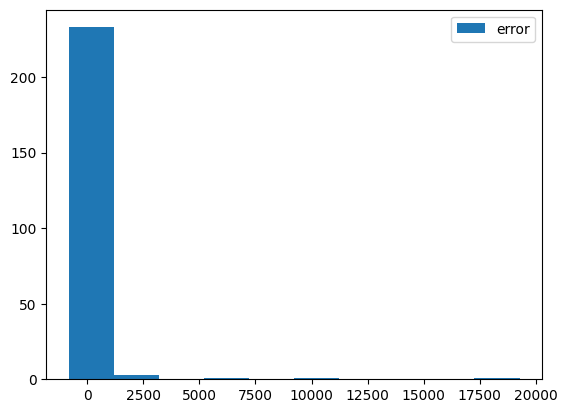

In [96]:
errors3=(predics3-T3)/T3*100
plt.hist(errors3[:,0])
plt.legend(['error'])
plt.show()

In [97]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T3[:,0], y=predics3[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T3[:,0], y=T3[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T3[:,0], y=errors3[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-10, 10], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

## mesh

In [98]:
x_mesh, y_mesh = np.linspace(0, 100, 31), np.linspace(20, 150, 31)
# x_mesh, y_mesh = np.arange(-1, 2, 0.1), np.arange(-1, 2, 0.1)
x_mesh, y_mesh = np.meshgrid(x_mesh, y_mesh)
x_mesh = x_mesh.flatten().reshape(31*31,1)
y_mesh = y_mesh.flatten().reshape(31*31,1)
mesh3=np.concatenate((x_mesh, y_mesh), axis=1)
x_mesh[:5]

array([[ 0.        ],
       [ 3.33333333],
       [ 6.66666667],
       [10.        ],
       [13.33333333]])

In [99]:
mesh_predics3=scaler_T3.inverse_transform(  bp3.run( scaler_X3.transform(mesh3) )  )

## plot

In [100]:
fig_predic=go.Figure()
fig_predic.add_trace(go.Scatter3d(x=data3[:,0], y=data3[:,1], z=data3[:,2], mode='markers', marker_size=6, name='data'))
fig_predic.add_trace(go.Scatter3d(x=data3[:,0], y=data3[:,1], z=predics3[:,0], mode='markers', marker_size=6, name='predics'))
fig_predic.add_trace(go.Scatter3d(x=x_mesh[:,0], y=y_mesh[:,0], z=mesh_predics3[:,0], mode='markers', marker_size=2, name='mesh-predics', visible='legendonly'))

fig_predic.update_layout(
    scene = {
        "xaxis": {"range":[0,100], "nticks": 20},
        "yaxis": {"range":[20,150], "nticks": 20},
        # "zaxis": {"range":[1.1,1.5], "nticks": 6},
        'xaxis_title': '%H3PO4',
        'yaxis_title': 'Temperature, C',
        'zaxis_title': 'Pressure, mbar',
        'camera_eye': {"x": 1.5, "y": -1.5, "z": .7},
        "aspectratio": {"x": 1, "y": 1, "z": 0.6},
        'camera_center': {"x": 0, "y": 0, "z": -0.01}
    },
    width=1000, height=1000,
    margin=dict(l=30, r=30, b=30, t=30),
    title_text=' ',
    title_x=0.5,
)
fig_predic.update_scenes(camera_projection_type="orthographic")
# fig_predic.write_html("Na,K..H2PO4,SO4 density ortho 170522.html")

fig_predic.show()

In [101]:
bp3.print_weights()

Layers (input, hidden, output):  [2, 4, 1] sigmoid linear
Hidden layer weights:  [[0.807284628292032, -2.529482016255705, 1.6353084608789454, 2.548967112384344], [-2.2278329733045674, -0.2852300972735734, 2.2181283348768397, -0.8321259264011612]]
Hidden layer biases:  [[3.357216785926395, -1.817122738265093, -6.368237983036172, 0.46260097605455747]]
Outlet layer weights:  [[-6.20677316410875], [-1.795114906436459], [-4.874143431009054], [-1.8255413731287133]]
Outlet layer biases:  [[7.243595471079233]]


In [102]:
bp3.export_weights_as_pandas()

,0,1,2,3
0,0.807285,-2.529482,1.635308,2.548967
1,-2.227833,-0.285230,2.218128,-0.832126
0,3.357217,-1.817123,-6.368238,0.462601
0,-6.206773,NaN,NaN,NaN
1,-1.795115,NaN,NaN,NaN
2,-4.874143,NaN,NaN,NaN
3,-1.825541,NaN,NaN,NaN
0,7.243595,NaN,NaN,NaN


In [103]:
print_scaler_data(scaler_data3)

scaler X -- mean, stdev:   [54.0167364  73.13807531] [30.67537774 34.91450667]
scaler T -- mean, stdev:   [305.48522594] [375.99549062]


# f(x1,x2,x3)

## data

In [104]:
data5=pd.DataFrame([[3.5432, 44.1176470588235, 39.7307914468193, 1.7787,
        17.1987641606591, 1.03129605623734, 'exp1'],
       [3.5432, 44.1176470588235, 46.7421075844933, 1.61172,
        14.2121524201854, 1.33418381984987, 'exp1'],
       [3.5432, 44.1176470588235, 53.7534237221673, 1.43143,
        11.6947472745292, 1.78559851572739, 'exp1'],
       [3.5432, 44.1176470588235, 60.7647398598413, 1.3224,
        9.75359342915811, 1.8067259420946, 'exp1'],
       [3.61182, 52.5, 33.2044509861419, 1.73556, 26.109391124871,
        1.2784366054216, 'exp2'],
       [3.61182, 52.5, 39.0640599836963, 1.50787, 23.0448383733055,
        1.30063890921072, 'exp2'],
       [3.61182, 52.5, 44.9236689812508, 1.28216, 18.3303085299456,
        1.6396367983226, 'exp2'],
       [3.61182, 52.5, 50.7832779788052, 1.15506, 15.3439153439153,
        1.6793895639359, 'exp2'],
       [3.546, 41.9753086419753, 48.1611135844767, 1.548,
        13.5922330097087, 1.58024190679573, 'exp4'],
       [3.546, 41.9753086419753, 48.1611135844767, 1.548,
        13.5922330097087, 1.58024190679573, 'exp4'],
       [3.546, 41.9753086419753, 55.3852806221482, 1.44056,
        11.2244897959184, 1.75311864093404, 'exp4'],
       [3.546, 41.9753086419753, 62.6094476598198, 1.37192,
        9.61538461538462, 2.33968055882646, 'exp4'],
       [3.15645, 37.3333333333333, 46.223478589122, 1.62281,
        13.6842105263158, 1.26494899078895, 'exp7'],
       [3.15645, 37.3333333333333, 54.3805630460259, 1.48603,
        11.340206185567, 1.53596150580697, 'exp7'],
       [3.15645, 37.3333333333333, 62.5376475029298, 1.39922,
        9.18367346938775, 2.0761800720865, 'exp7'],
       [3.15645, 37.3333333333333, 70.6947319598337, 1.3311,
        7.54716981132076, 2.46615102122547, 'exp7'],
       [3.21264, 48.4375, 35.9576897475555, 1.424, 20.0,
        0.877430345937249, 'exp8'],
       [3.21264, 48.4375, 42.3031644088888, 1.25664, 17.3469387755102,
        1.21143181315366, 'exp8'],
       [3.21264, 48.4375, 48.6486390702222, 1.1736, 14.8514851485148,
        1.51090731456155, 'exp8'],
       [3.21264, 48.4375, 54.9941137315555, 1.0787, 12.8712871287129,
        2.10993639581657, 'exp8'],
       [3.17988, 57.7039274924471, 29.8573774179341, 1.2664,
        28.2178217821782, 0.922752144650929, 'exp9'],
       [3.17988, 57.7039274924471, 35.1263263740401, 1.0569,
        24.3731193580742, 1.1326227604219, 'exp9'],
       [3.17988, 57.7039274924471, 40.3952753301461, 0.9309,
        20.4901960784314, 1.2410533380211, 'exp9'],
       [3.17988, 57.7039274924471, 45.6642242862522, 0.87596,
        18.034188034188, 1.58738143967855, 'exp9']],columns=['SO4_in', 'FA_in', 'DCP_in',	'SO4', 'FA', 'P2O5_norm',	'exp'])

In [105]:
# data5=pd.read_csv('new_dcp_data.csv')
data5.iloc[:,[0,1,2,3,4,5,6]]

,SO4_in,FA_in,DCP_in,SO4,FA,P2O5_norm,exp
0,3.54320,44.117647,39.730791,1.77870,17.198764,1.031296,exp1
1,3.54320,44.117647,46.742108,1.61172,14.212152,1.334184,exp1
2,3.54320,44.117647,53.753424,1.43143,11.694747,1.785599,exp1
3,3.54320,44.117647,60.764740,1.32240,9.753593,1.806726,exp1
4,3.61182,52.500000,33.204451,1.73556,26.109391,1.278437,exp2
5,3.61182,52.500000,39.064060,1.50787,23.044838,1.300639,exp2
6,3.61182,52.500000,44.923669,1.28216,18.330309,1.639637,exp2
7,3.61182,52.500000,50.783278,1.15506,15.343915,1.679390,exp2
8,3.54600,41.975309,48.161114,1.54800,13.592233,1.580242,exp4
9,3.54600,41.975309,48.161114,1.54800,13.592233,1.580242,exp4


In [106]:
X5=np.array(data5)[:,[0,1,2]]
T5=np.array(data5)[:,[3,4,5]]

## scaling

In [107]:
scaler_X5 = preprocessing.StandardScaler().fit(X5)
scaler_T5 = preprocessing.StandardScaler().fit(T5)

# scaler_X5.mean_, scaler_X5.scale_ = np.zeros(X5.shape[1]), np.ones(X5.shape[1]) # disable scaling
# scaler_T5.mean_, scaler_T5.scale_ = np.zeros(T5.shape[1]), np.ones(T5.shape[1]) # disable scaling

scaler_data5 = [scaler_X5.mean_, scaler_X5.scale_, scaler_T5.mean_, scaler_T5.scale_]
print('scaler X -- mean, stdev:  ',scaler_data5[0], scaler_data5[1])
print('scaler T -- mean, stdev:  ',scaler_data5[2], scaler_data5[3])

X_sc5 = scaler_X5.transform(X5)
T_sc5 = scaler_T5.transform(T5)
X_sc5[0:3]

scaler X -- mean, stdev:   [ 3.37499833 47.01128609 47.91944614] [ 0.19399856  6.75635049 10.01060258]
scaler T -- mean, stdev:   [ 1.35981833 15.90218114  1.5435811 ] [0.22990127 5.44826372 0.40863675]


array([[ 0.86702535, -0.42828433, -0.81799818],
       [ 0.86702535, -0.42828433, -0.11760916],
       [ 0.86702535, -0.42828433,  0.58277986]])

## parameter searching

In [108]:
bp_iter=VectorBackProp(layers=[3,6,3], hidden_activation = 'prelu')
learning_rate = [0.001, 0.005, 0.01]
momentum_term = [0.8, 0.9, 0.95]
learning_rate_decay = [0]
repeats = range(10)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X_sc5, T_sc5, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], bp_iter.loss_list[-2] - bp_iter.loss_list[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                if i%25==0 and i>0:
                    print ('\n')
                i+=1

total runs: 90
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 

26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 

76 77 78 79 80 81 82 83 84 85 86 87 88 89 

In [109]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'final_loss_gradient'])
output_table.fillna(value = 1.1, inplace = True)
output_table.head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,final_loss_gradient
0,0.001,0.8,0.0,0.108206,0.000002
1,0.001,0.8,0.0,0.103955,0.000057
2,0.001,0.8,0.0,0.076607,0.000003
3,0.001,0.8,0.0,0.065804,0.000011
4,0.001,0.8,0.0,0.083406,0.000015


In [110]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.2],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'final_loss_gradient', values = output_table['final_loss_gradient']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'grey',
    paper_bgcolor = 'beige'
)

fig.show()

## running best parameters

In [111]:
bp_iter=VectorBackProp(layers=[3,6,3], hidden_activation = 'prelu')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X_sc5, T_sc5, epochs=1000, learning_rate = 0.01, momentum_term = 0.9, learning_rate_decay = 0., repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [112]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.1])
fig2.show()

## best_weights_for_now

In [113]:
best_weights_for_now5=weights_lists2[11]
best_weights_for_now5

[[[0.7925663422094159,
   1.0708019923407803,
   -0.4871555752754055,
   0.48292502696185324,
   -0.5874778019994349,
   -0.7904095009175778],
  [0.8194399330976818,
   -0.00043866402597399256,
   1.029348687367386,
   -0.7875991718898168,
   -0.5734098743929299,
   0.942966899262262],
  [-1.8005922044148313,
   0.13732816179611462,
   0.02454090926777921,
   -1.3140804469641494,
   0.7434653301116861,
   0.7275001752611497]],
 [[-1.483083162219716,
   1.180030946466346,
   0.8750453204819718,
   0.37798953149623143,
   0.8706917710190744,
   -0.010442484833392026]],
 [[0.4725223744605404, 0.534654334486837, -0.4464540231823916],
  [-0.40264749389785315, -0.20054485209481698, 1.3055142706007914],
  [-1.1552675489345374, 0.41561581444080087, 1.1187189925062297],
  [0.44704543057968243, 0.268237004791416, 0.22262403140067671],
  [-0.33769669081052583, -0.2668422591174357, 1.4690490940019716],
  [-0.012027776913510663, -0.2787354540220159, 0.2333943310017712]],
 [[1.423472262997919, -0.13

In [114]:
manual_best_weights_for_now5=[[[0.8535201744981578,
   0.23891613325375433,
   -0.3706213592894098,
   -0.4319215564257858,
   0.5806683166099315,
   -0.45312440005788335],
  [-1.3954718784061861,
   -0.695150962232366,
   1.1092111487917213,
   0.5088073751345356,
   0.5475099337474189,
   0.9996855926675174],
  [0.2864841341539176,
   -0.9760182043221927,
   0.13147906109812887,
   1.176281755284305,
   -0.8627091456740976,
   -0.9969945042729156]],
 [[-1.7087073195023568,
   0.23484366855236094,
   0.904933268468465,
   -0.521738685225468,
   -0.7736711357904624,
   1.1694566633838352]],
 [[-0.37439150804139865, -0.12464629196196286, 2.250932496148333],
  [0.6951467932848032, 0.43765573963810295, -0.3777968880846245],
  [-1.089233486958558, 0.16654587440970814, 0.7755593752719424],
  [-0.16760703937947458, -0.34873049602012374, 1.087041365827288],
  [0.5250137257120451, 0.7309124150382786, 0.6503922051030756],
  [0.25020352808877644, 0.31343691683212843, -0.8403323706548815]],
 [[0.2889052934673156, -0.9086179498937622, 0.19248109225363927]]]

 # epochs=1000, learning_rate = 0.01, momentum_term = 0.9, learning_rate_decay = 0.
 # loss = 0.0284

## fitting best parameters

In [115]:
bp5=VectorBackProp(layers=[3,6,3], hidden_activation = 'prelu')

In [116]:
# bp5.fit_graddescent(X_sc5, T_sc5, epochs=3000, eps=0.001, repeat=False)
# bp5.import_weights(best_weights_for_now5)
bp5.import_weights(manual_best_weights_for_now5)
bp5.fit(X_sc5, T_sc5, epochs=10000, learning_rate = 0.01, momentum_term = 0.9, learning_rate_decay = 1., repeat=True)

In [117]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp5.loss_list[20:], name=''))
print('Initial loss =', bp5.loss_list[0])
print('Final loss =', bp5.loss_list[-1])
fig1.show()

Initial loss = 0.028382879846776662
Final loss = 0.028332913247589218


## prediction

In [118]:
predics5=scaler_T5.inverse_transform(bp5.run(X_sc5))
predics5

array([[ 1.76312938, 17.41844692,  1.03526098],
       [ 1.56641473, 13.88102083,  1.35765046],
       [ 1.40697973, 11.5291594 ,  1.65393958],
       [ 1.34080709, 10.44312998,  1.8861871 ],
       [ 1.72474082, 26.84907641,  1.21347743],
       [ 1.51962687, 22.5469824 ,  1.393421  ],
       [ 1.31451293, 18.24488838,  1.57336458],
       [ 1.15982684, 14.69654058,  1.70471165],
       [ 1.56858714, 13.14151085,  1.5581039 ],
       [ 1.56858714, 13.14151085,  1.5581039 ],
       [ 1.43818505, 11.31210133,  1.85873091],
       [ 1.36505542,  9.75083964,  2.28497975],
       [ 1.63012994, 14.35783935,  1.3023633 ],
       [ 1.47885926, 11.74146984,  1.56925502],
       [ 1.38857884,  9.12306897,  2.04622571],
       [ 1.34286875,  7.33095221,  2.48299508],
       [ 1.44146255, 19.68740573,  0.85095804],
       [ 1.2851706 , 17.20457264,  1.19052034],
       [ 1.15653987, 15.08936461,  1.51752065],
       [ 1.07030573, 12.66875284,  2.09249308],
       [ 1.2483389 , 27.84728955,  0.964

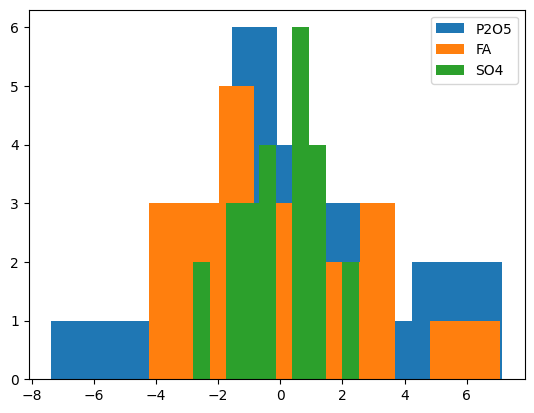

In [119]:
pred=predics5
predics5_y1_vbp=pred[:,0]
error5_y1_vbp=(predics5_y1_vbp-T5[:,0])/T5[:,0]*100
predics5_y2_vbp=pred[:,1]
error5_y2_vbp=(predics5_y2_vbp-T5[:,1])/T5[:,1]*100
predics5_y3_vbp=pred[:,2]
error5_y3_vbp=(predics5_y3_vbp-T5[:,2])/T5[:,2]*100

plt.hist(error5_y3_vbp)
plt.hist(error5_y2_vbp)
plt.hist(error5_y1_vbp)
plt.legend(['P2O5', 'FA', 'SO4'])
plt.show()

In [120]:
fig = make_subplots(rows=1, cols=3, subplot_titles=("SO4", "FA", "P2O5"), column_widths=[0.33, 0.33, 0.33],
                     specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]])

fig.add_trace(go.Scatter(x=T5[:,0] , y=predics5_y1_vbp, mode='markers', marker_size=4, text=data5.exp, name='predics SO4', marker_color='black' ), 1, 1)
fig.add_trace(go.Scatter(x=T5[:,1] , y=predics5_y2_vbp, mode='markers', marker_size=4, text=data5.exp, name='predics FA', marker_color='black' ), 1, 2)
fig.add_trace(go.Scatter(x=T5[:,2] , y=predics5_y3_vbp, mode='markers', marker_size=4, text=data5.exp, name='predics P2O5', marker_color='black' ), 1, 3)

fig.add_trace(go.Scatter(x=T5[:,0] , y=error5_y1_vbp, mode='markers', marker_size=4, text=data5.exp, name='error SO4', marker_color='orange' ), 1, 1, secondary_y=True,)
fig.add_trace(go.Scatter(x=T5[:,1] , y=error5_y2_vbp, mode='markers', marker_size=4, text=data5.exp, name='error FA', marker_color='orange' ), 1, 2, secondary_y=True,)
fig.add_trace(go.Scatter(x=T5[:,2] , y=error5_y3_vbp, mode='markers', marker_size=4, text=data5.exp, name='error P2O5', marker_color='orange' ), 1, 3, secondary_y=True,)

fig.update_layout(title='', autosize=True,
                  width=1550, height=400,
                  margin=dict(l=0, r=0, b=0, t=30))

fig.update_xaxes(title_text="", range=[0.5, 2], row=1, col=1)
fig.update_yaxes(title_text="", range=[0.5, 2], row=1, col=1)
fig.update_yaxes(title_text="%error", range=[-10, 10], row=1, col=1, secondary_y=True, showgrid=False, tick0=-10, dtick=2)

fig.update_xaxes(title_text="", range=[0, 30], row=1, col=2)
fig.update_yaxes(title_text="", range=[0, 30], row=1, col=2)
fig.update_yaxes(title_text="%error", range=[-10, 10], row=1, col=2, secondary_y=True, showgrid=False, tickvals=[-10,-5,-1,0,1,5,10])

fig.update_xaxes(title_text="", range=[0.5, 2], row=1, col=3)
fig.update_yaxes(title_text="", range=[0.5, 2], row=1, col=3)
fig.update_yaxes(title_text="%error", range=[-10, 10], row=1, col=3, secondary_y=True, showgrid=False, tick0=-10, dtick=2)

fig.show()

In [121]:
bp5.export_weights_as_pandas()

,0,1,2,3,4,5
0,0.853144,0.238942,-0.372561,-0.433294,0.580311,-0.455630
1,-1.395156,-0.695365,1.112327,0.507098,0.548502,1.004759
2,0.288903,-0.975012,0.132179,1.175798,-0.861742,-0.990940
0,-1.709658,0.236085,0.907535,-0.520639,-0.773799,1.174458
0,-0.372478,-0.127210,2.251795,NaN,NaN,NaN
1,0.694693,0.438158,-0.376645,NaN,NaN,NaN
2,-1.089216,0.162082,0.785024,NaN,NaN,NaN
3,-0.166791,-0.347998,1.086050,NaN,NaN,NaN
4,0.524726,0.731897,0.648902,NaN,NaN,NaN
5,0.252713,0.314919,-0.846228,NaN,NaN,NaN


# 3-2-1 with confidence

## data

In [122]:
data=CopyPasteToArray('''
Sample	MgCl2	NaCl	Solvent	T	Confidences
60-1	74.4	10.1	67.3	60	0
60-2	75.8	8.80	67.1	60	0
60-3	76.8	7.56	66.4	60	0
60-t	77.5	5.80	65.5	60	1
60-4	81.8	5.05	66.5	60	0.1
60-5	88.0	4.20	68.1	60	5
60-6	92.8	2.47	68.0	60	5
60-7	97.5	1.21	66.5	60	5
Na_Mg-60	70	30	73.3	60	1
Na_Mg-60	75	25	73.0	60	1
Na_Mg-60	80	20	72.5	60	1
Na_Mg-60	85	15	71.3	60	1
Na_Mg-60	90	10	69.3	60	1
Na_Mg-60	95	5	66.1	60	1
80-1	73.0	9.44	67.7	80	1
80-2	73.8	8.23	66.0	80	1
80-3	74.5	7.22	65.0	80	1
80-t	75.5	5.70	63.4	80	1
80-5	77.3	5.69	64.1	80	1
80-6	79.7	4.90	65.5	80	1
80-6b	81.3	4.57	65.7	80	1
80-7	85.1	4.30	66.3	80	1
80-7b	87.2	3.60	65.7	80	1
80-8	91.7	2.97	65.6	80	1
80-9	93.5	2.40	65.2	80	1
Na_Mg-80	70	30	72.6	80	1
Na_Mg-80	75	25	72.3	80	1
Na_Mg-80	80	20	71.6	80	1
Na_Mg-80	85	15	70.2	80	1
Na_Mg-80	90	10	67.9	80	1
Na_Mg-80	95	5	64.4	80	1
''')
# data
np_data=np.array(data)
data_cols=pd.DataFrame(np_data[1:,1:6], dtype=float)
text_cols1=pd.DataFrame(np_data[1:,0])
# text_cols2=pd.DataFrame(np_data[1:,4])
df_satur3=pd.concat([
                    text_cols1,
                    data_cols,
                    # text_cols2
                    ], axis=1)
df_satur3.columns=np_data[0]
df_satur3.head(3)

,Sample,MgCl2,NaCl,Solvent,T,Confidences
0,60-1,74.4,10.10,67.3,60.0,0.0
1,60-2,75.8,8.80,67.1,60.0,0.0
2,60-3,76.8,7.56,66.4,60.0,0.0


In [123]:
n=14
df=df_satur3.copy()
Satur60_3=go.Scatter3d(x=df.MgCl2[0:n], y=df.NaCl[0:n], z=df.Solvent[0:n], text=df.Sample[0:n], name='Saturation 60C tests', mode='markers', marker_color='tan', marker_size=4, opacity = 0.8)
Satur80_3=go.Scatter3d(x=df.MgCl2[n:], y=df.NaCl[n:], z=df.Solvent[n:], text=df.Sample[n:], name='Saturation 80C tests', mode='markers', marker_color='brown', marker_size=4, opacity = 0.8)

In [124]:
fig = go.Figure()

fig.add_trace(Satur60_3)
fig.add_trace(Satur80_3)

fig.update_layout(
        scene = {
            'camera_eye': {"x": 0., "y": -0.01, "z": 1.5},
            "aspectratio": {"x": 1, "y": 1, "z": 2},
            'camera_center': {"x": 0, "y": 0, "z": -0.1},
            'xaxis': {'range': [0, 100], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'yaxis': {'range': [0, 100], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'zaxis': {'range': [0, 100], 'dtick': 10, 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
        },
        width=900, height=900,
        margin=dict(l=0, r=0, b=0, t=0),
        legend_y=0.9,
)
fig.update_scenes(camera_projection_type="orthographic")

# fig.write_html("DSW Experiment Iso 60C 061024.html")
fig.show()

In [125]:
df_satur3.head()

,Sample,MgCl2,NaCl,Solvent,T,Confidences
0,60-1,74.4,10.10,67.3,60.0,0.0
1,60-2,75.8,8.80,67.1,60.0,0.0
2,60-3,76.8,7.56,66.4,60.0,0.0
3,60-t,77.5,5.80,65.5,60.0,1.0
4,60-4,81.8,5.05,66.5,60.0,0.1


In [126]:
X1=np.array(df_satur3)[:,[1,2,4]]
T1=np.array(df_satur3)[:,[3]]
# conf1=np.ones_like(T1)
conf1=np.array(df_satur3)[:,[5]]

## manual_sigmoid function

In [127]:
import numpy as np
import matplotlib.pyplot as plt

def manual_sigmoid(
    x: np.ndarray,
    x_mid: float,
    y_min: float,
    y_max: float,
    steepness: float = 1.0
) -> np.ndarray:
    """
    Generates y-values for a sigmoid-like curve based on input x-values.

    The curve is defined by a minimum and maximum y-value, and its inflection point
    (the center of the "S" shape) is explicitly set at `x_mid`.

    Args:
        x (np.ndarray): The array of input x-values for which to calculate y-values.
        x_mid (float): The x-value that corresponds to the inflection point of the
                       sigmoid curve. The y-value at this point will be (y_min + y_max) / 2.
        y_min (float): The lower asymptote (minimum value) of the sigmoid curve.
        y_max (float): The upper asymptote (maximum value) of the sigmoid curve.
        steepness (float, optional): A factor to control the sharpness of the curve.
                                     Values > 1.0 make it steeper. Defaults to 1.0.

    Returns:
        np.ndarray: The calculated y-values forming the sigmoid curve.

    Raises:
        ValueError: If x_mid is not within the range of the input x data.
    """
    # 1. Get x_min and x_max from the data itself
    x_min = np.min(x)
    x_max = np.max(x)

    # 2. Check that x_mid is within the valid range
    if not (x_min <= x_mid <= x_max):
        raise ValueError(f"x_mid ({x_mid}) must be between x_min ({x_min}) and x_max ({x_max}).")

    # 3. Normalize the x-values so that x_mid becomes the zero point.
    # This is a two-part linear scaling to map the range [x_min, x_max] to [-1, 1],
    # with the zero-crossing precisely at x_mid.
    x_normalized = np.zeros_like(x, dtype=float)

    # Handle values before the midpoint
    mask_before = x <= x_mid
    if x_mid > x_min:  # Avoid division by zero if x_mid is the same as x_min
        x_normalized[mask_before] = (x[mask_before] - x_mid) / (x_mid - x_min)

    # Handle values after the midpoint
    mask_after = x > x_mid
    if x_max > x_mid:  # Avoid division by zero if x_mid is the same as x_max
        x_normalized[mask_after] = (x[mask_after] - x_mid) / (x_max - x_mid)

    # 4. Create the sigmoid curve
    # The normalized range is now [-1, 1]. We scale it for the sigmoid function's input.
    # A multiplier of 6 maps this to a nice [-6, 6] range.
    sigmoid_input = x_normalized * 6 * steepness

    # The standard logistic function: 1 / (1 + e^-z)
    sigmoid_output = 1 / (1 + np.exp(-sigmoid_input))

    # 5. Scale the output [0, 1] to the desired y-range [y_min, y_max]
    y_calculated = y_min + sigmoid_output * (y_max - y_min)

    return y_calculated

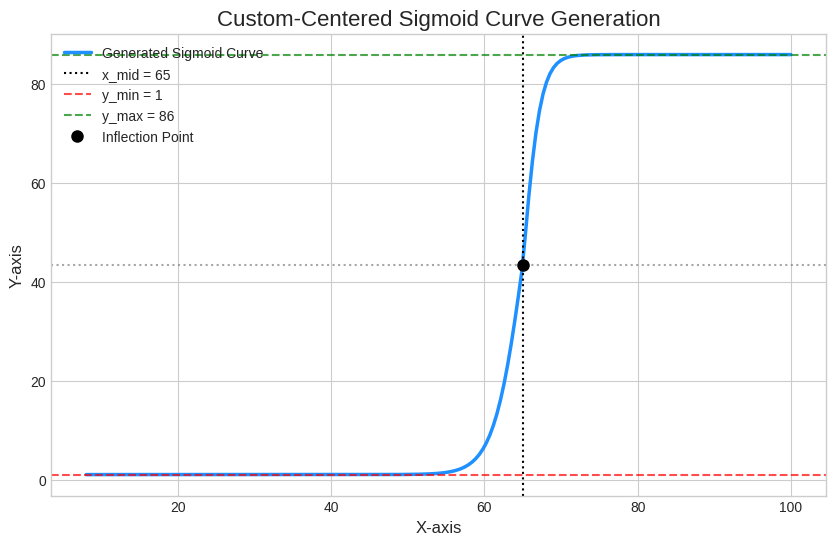

In [128]:
# --- 1. Setup Parameters ---
# Define the range for our x-axis
x_values = np.linspace(8, 100, 200)

# Define the properties of our desired sigmoid curve
y_target_min = 1
y_target_max = 86
x_mid_point = 65  # The inflection point of the curve
steepness_factor = 5 # A slightly sharper curve

# --- 2. Generate the Sigmoid Data ---
# Use the function to calculate the y-values
y_sigmoid_values = manual_sigmoid(
    x=x_values,
    x_mid=x_mid_point,
    y_min=y_target_min,
    y_max=y_target_max,
    steepness=steepness_factor
)

# --- 3. Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the generated sigmoid curve
ax.plot(x_values, y_sigmoid_values, color='dodgerblue', linewidth=2.5, label='Generated Sigmoid Curve')

# Add visual aids to verify the function's behavior
ax.axvline(x=x_mid_point, color='k', linestyle=':', linewidth=1.5, label=f'x_mid = {x_mid_point}')
ax.axhline(y=y_target_min, color='r', linestyle='--', alpha=0.7, label=f'y_min = {y_target_min}')
ax.axhline(y=y_target_max, color='g', linestyle='--', alpha=0.7, label=f'y_max = {y_target_max}')
mid_y_val = (y_target_min + y_target_max) / 2
ax.axhline(y=mid_y_val, color='gray', linestyle=':', alpha=0.7)
ax.plot(x_mid_point, mid_y_val, 'ko', markersize=8, label='Inflection Point')


# Formatting
ax.set_title('Custom-Centered Sigmoid Curve Generation', fontsize=16)
ax.set_xlabel('X-axis', fontsize=12)
ax.set_ylabel('Y-axis', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True)
plt.show()

In [129]:
conf_sigm = manual_sigmoid(
    x=X1[:,0],
    x_mid=80,
    y_min=0,
    y_max=10,
    steepness = 1.0)
conf_sigm

array([0.33569223, 0.74467945, 1.27861566, 1.82425524, 6.49568457,
       9.39508678, 9.87733869, 9.97527377, 0.02472623, 0.47425873,
       5.        , 8.47391335, 9.68585629, 9.94192942, 0.14774032,
       0.23660578, 0.35571189, 0.62973356, 1.6520487 , 4.55121108,
       6.09619785, 8.51772527, 9.2190898 , 9.82214541, 9.903258  ,
       0.02472623, 0.47425873, 5.        , 8.47391335, 9.68585629,
       9.94192942])

## scaling

In [130]:
scaler_X1 = preprocessing.StandardScaler().fit(X1)
scaler_T1 = preprocessing.StandardScaler().fit(T1)

# scaler_X1.mean_, scaler_X1.scale_ = 0, 1 # disable scaling
# scaler_T1.mean_, scaler_T1.scale_ = 0, 1 # disable scaling

scaler_data1 = [scaler_X1.mean_, scaler_X1.scale_, scaler_T1.mean_, scaler_T1.scale_]
print('scaler X -- mean, stdev:  ',scaler_data1[0], scaler_data1[1])
print('scaler T -- mean, stdev:  ',scaler_data1[2], scaler_data1[3])

X_sc1 = scaler_X1.transform(X1)
T_sc1 = scaler_T1.transform(T1)
X_sc1[0:3]

scaler X -- mean, stdev:   [82.16774194 10.13580645 70.96774194] [7.93348913 8.13385231 9.95306363]
scaler T -- mean, stdev:   [67.74516129] [2.86995995]


array([[-0.97910791, -0.00440215, -1.10194633],
       [-0.80264078, -0.16422802, -1.10194633],
       [-0.67659284, -0.31667731, -1.10194633]])

## parameter searching

In [131]:
bp_iter=VectorBackProp(layers=[3,2,1], hidden_activation = 'sigmoid')
learning_rate = [0.01, 0.05, .1]
momentum_term = [0.90, 0.95, 0.97]
learning_rate_decay = [0]
repeats = range(5)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X_sc1, T_sc1, epochs=1000, confidences=conf1, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                i+=1


total runs: 45
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 

/content/MLNN.py:37: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/content/MLNN.py:97: RuntimeWarning:

overflow encountered in multiply

/content/MLNN.py:93: RuntimeWarning:

overflow encountered in square

/content/MLNN.py:97: RuntimeWarning:

invalid value encountered in multiply

/content/MLNN.py:125: RuntimeWarning:

overflow encountered in matmul

/content/MLNN.py:125: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-667540624.py:16: RuntimeWarning:

invalid value encountered in scalar divide

/tmp/ipython-input-667540624.py:16: RuntimeWarning:

invalid value encountered in scalar subtract



37 38 39 40 41 42 43 44 

In [132]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.sort_values('final_loss').head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
8,0.01,0.95,0.0,0.049673,-0.006063
12,0.01,0.97,0.0,0.064806,-0.000128
22,0.05,0.95,0.0,0.069813,-0.003934
24,0.05,0.95,0.0,0.072247,-0.000700
17,0.05,0.90,0.0,0.073876,-0.003310


In [133]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.05],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [134]:
bp_iter=VectorBackProp(layers=[3,2,1], hidden_activation = 'sigmoid')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X_sc1, T_sc1, epochs=2000, confidences=conf1, learning_rate = 0.005, momentum_term = 0.95, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [135]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.05], title='Loss')
fig2.show()

## best_weights_for_now

In [136]:
# best_weights_for_now1=weights_list[14]  # list from parameter searching

In [137]:
best_weights_for_now1=weights_lists2[17]
best_weights_for_now1

[[[2.9923429653704865, 0.46857011736672666],
  [-2.946029598297026, 5.523791649579699],
  [6.650043272331064, 0.9922804105185224]],
 [[-1.9158085723156704, -0.936938497191589]],
 [[-0.975146956581498], [1.741969350892868]],
 [[0.009238824653630092]]]

In [138]:
manual_best_weights_for_now1=[[[0.5859013836185065, -2.427467086177052],
  [-0.358692128560213, -3.944716641580931],
  [0.3306991439712676, -0.20003285128791684]],
 [[-1.2766725986641019, -3.676814823608575]],
 [[-5.359421698190241], [-4.216632659134087]],
 [[2.1127433032050575]]]

 # 2 sigmoids
 # epochs=1000, learning_rate = 0.005, momentum_term = 0.95, learning_rate_decay = 0
 # loss = .031

## fitting best parameters

In [139]:
bp1=VectorBackProp(layers=[3,2,1], hidden_activation = 'sigmoid')

In [140]:
# bp1.import_weights(best_weights_for_now1)
bp1.import_weights(manual_best_weights_for_now1)
bp1.fit(X_sc1, T_sc1, epochs=2000, confidences=conf1, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 1, repeat=True)

In [141]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
# fig1.show()

Initial loss = 0.03130375785750113
Final loss = 0.03130346286732567


## prediction

In [142]:
predics1=scaler_T1.inverse_transform(bp1.run(X_sc1))
# predics1

In [143]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

In [144]:
marker_sizes = 4
marker_sizes = ((conf1[:,0] - conf1[:,0].min()) / (conf1[:,0].max() - conf1[:,0].min()) * (10-4) + 4).astype(float) # confidence

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=marker_sizes, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=marker_sizes, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

# Set y-axes titles
fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

## mesh

In [145]:
x_mesh, y_mesh, t_mesh = np.linspace(70, 96, 27), np.linspace(0, 40, 41), np.linspace(60, 80, 3)
x_mesh, y_mesh, t_mesh = np.meshgrid(x_mesh, y_mesh, t_mesh)
x_mesh = x_mesh.flatten().reshape(27*41*3,1)
y_mesh = y_mesh.flatten().reshape(27*41*3,1)
t_mesh = t_mesh.flatten().reshape(27*41*3,1)
mesh1=np.concatenate((x_mesh, y_mesh, t_mesh), axis=1)
x_mesh[:5]

array([[70.],
       [70.],
       [70.],
       [71.],
       [71.]])

**mesh filter**

In [146]:
sum=x_mesh[:,0]+y_mesh[:,0]
sum<=100  # inside the triangle
x_mesh=x_mesh[sum<=100]
y_mesh=y_mesh[sum<=100]
t_mesh=t_mesh[sum<=100]
mesh1=np.concatenate((x_mesh, y_mesh, t_mesh), axis=1)
t_mesh[:5]

array([[60.],
       [70.],
       [80.],
       [60.],
       [70.]])

In [147]:
mesh1 #x,y,T

array([[70.,  0., 60.],
       [70.,  0., 70.],
       [70.,  0., 80.],
       ...,
       [70., 30., 60.],
       [70., 30., 70.],
       [70., 30., 80.]])

**עד כאן**

In [148]:
mesh_predics1=scaler_T1.inverse_transform(bp1.run(scaler_X1.transform(mesh1)))

In [149]:
solub_surfaces=go.Scatter3d(x=x_mesh[:,0], y=y_mesh[:,0], z=mesh_predics1[:,0], mode='markers', text=t_mesh[:,0], marker_color='gray', marker_size=1, name='surface mesh-predics', visible=True)

In [150]:
T=60  # סינון לפי טמפרטורה
solub_surface_60=go.Scatter3d(x=x_mesh[t_mesh[:,0]==T,0], y=y_mesh[t_mesh[:,0]==T,0], z=mesh_predics1[t_mesh[:,0]==T,0], mode='markers', text=t_mesh[t_mesh[:,0]==T,0], marker_color='tan', marker_size=1, name='surface mesh-predics 60C', visible=True)
T=80  # סינון לפי טמפרטורה
solub_surface_80=go.Scatter3d(x=x_mesh[t_mesh[:,0]==T,0], y=y_mesh[t_mesh[:,0]==T,0], z=mesh_predics1[t_mesh[:,0]==T,0], mode='markers', text=t_mesh[t_mesh[:,0]==T,0], marker_color='brown', marker_size=1, name='surface mesh-predics 80C', visible=True)

## Simulator results

In [151]:
fig = go.Figure()

# fig.add_trace(Satur60)
# fig.add_trace(Satur80)
fig.add_trace(Satur60_3)
fig.add_trace(Satur80_3)
fig.add_trace(solub_surfaces)
fig.add_trace(solub_surface_60)
fig.add_trace(solub_surface_80)

fig.update_layout(
        scene = {
            'camera_eye': {"x": 0., "y": -0.01, "z": 1.5},
            "aspectratio": {"x": 1, "y": 1, "z": 1},
            'camera_center': {"x": 0, "y": 0, "z": -0.1},
            'xaxis': {'range': [70, 100], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'yaxis': {'range': [0, 30], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'zaxis': {'range': [50, 75], 'dtick': 10, 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
        },
        width=900, height=900,
        margin=dict(l=0, r=0, b=0, t=0),
        legend_y=0.9,
)
fig.update_scenes(camera_projection_type="orthographic")

# fig.write_html("DSW Solubility 181224.html")
fig.show()

## output

In [152]:
bp1.print_weights()

Layers (input, hidden, output):  [3, 2, 1] sigmoid linear
Hidden layer weights:  [[0.5858551109137577, -2.4273911708107003], [-0.3586241087323709, -3.9446498508475965], [0.3306591322011618, -0.20001509965388792]]
Hidden layer biases:  [[-1.2768400626158392, -3.6767308448415617]]
Outlet layer weights:  [[-5.360354564757871], [-4.216709263961955]]
Outlet layer biases:  [[2.1128108131565213]]


In [153]:
bp1.export_weights()

[[[0.5858551109137577, -2.4273911708107003],
  [-0.3586241087323709, -3.9446498508475965],
  [0.3306591322011618, -0.20001509965388792]],
 [[-1.2768400626158392, -3.6767308448415617]],
 [[-5.360354564757871], [-4.216709263961955]],
 [[2.1128108131565213]]]

In [154]:
bp1.export_weights_as_pandas()

,0,1
0,0.585855,-2.427391
1,-0.358624,-3.944650
2,0.330659,-0.200015
0,-1.276840,-3.676731
0,-5.360355,NaN
1,-4.216709,NaN
0,2.112811,NaN


In [155]:
bp1.export_weights_as_pandas()

,0,1
0,0.585855,-2.427391
1,-0.358624,-3.944650
2,0.330659,-0.200015
0,-1.276840,-3.676731
0,-5.360355,NaN
1,-4.216709,NaN
0,2.112811,NaN


In [156]:
print_scaler_data(scaler_data1)

scaler X -- mean, stdev:   [82.16774194 10.13580645 70.96774194] [7.93348913 8.13385231 9.95306363]
scaler T -- mean, stdev:   [67.74516129] [2.86995995]


In [157]:
pd.DataFrame(scaler_data1)

,0,1,2
0,82.167742,10.135806,70.967742
1,7.933489,8.133852,9.953064
2,67.745161,NaN,NaN
3,2.869960,NaN,NaN


In [158]:
scaler_T1.inverse_transform(bp1.run(scaler_X1.transform([[60,40,60],[70,24,80]])))

array([[73.65480134],
       [72.61459812]])